In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
# ==========================================
# 1. INSTALLATION & SETUP
# ==========================================
import os

# Clone repo nếu chưa có
if not os.path.exists("yolov12"):
    !git clone https://github.com/sunsmarterjie/yolov12.git

# Di chuyển vào thư mục yolov12
%cd yolov12

# Cài đặt các thư viện cần thiết
!pip install -q -r requirements.txt
!pip install -q -e .

# Cài thêm thư viện hỗ trợ xử lý dữ liệu (nếu thiếu)
!pip install -q roboflow matplotlib seaborn opencv-python

Cloning into 'yolov12'...
remote: Enumerating objects: 1163, done.
remote: Counting objects: 100% (663/663), done.
remote: Compressing objects: 100% (205/205), done.
remote: Total 1163 (delta 493), reused 458 (delta 458), pack-reused 500 (from 1)
Receiving objects: 100% (1163/1163), 1.80 MiB | 14.05 MiB/s, done.
Resolving deltas: 100% (584/584), done.
/kaggle/working/yolov12
ERROR: Could not install packages due to an OSError: [Errno 2] No such file or directory: '/kaggle/working/yolov12/flash_attn-2.7.3+cu11torch2.2cxx11abiFALSE-cp311-cp311-linux_x86_64.whl'

  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 100.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4

In [3]:
!wget https://github.com/Dao-AILab/flash-attention/releases/download/v2.7.3/flash_attn-2.7.3+cu11torch2.2cxx11abiFALSE-cp311-cp311-linux_x86_64.whl

--2025-12-03 14:02:51--  https://github.com/Dao-AILab/flash-attention/releases/download/v2.7.3/flash_attn-2.7.3+cu11torch2.2cxx11abiFALSE-cp311-cp311-linux_x86_64.whl
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/494232964/b7fb7022-424c-4ac2-b46b-a41f386edaa5?sp=r&sv=2018-11-09&sr=b&spr=https&se=2025-12-03T14%3A48%3A40Z&rscd=attachment%3B+filename%3Dflash_attn-2.7.3%2Bcu11torch2.2cxx11abiFALSE-cp311-cp311-linux_x86_64.whl&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2025-12-03T13%3A48%3A05Z&ske=2025-12-03T14%3A48%3A40Z&sks=b&skv=2018-11-09&sig=FqYofuu05RqouihXiQgc75GXGX1YygNX8gOkOPNHJyw%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbn

In [4]:
import os
import json
import shutil
import yaml
import numpy as np
from pathlib import Path
from ultralytics import YOLO

# ==========================================
# 2. DATA PREPARATION
# ==========================================
# ⚠️ Thay đường dẫn Input của bạn vào đây:
SRC_ROOT = Path("/kaggle/input/sh17-2") 

# Output ra thư mục ngoài (ngang hàng với folder yolov12)
DST_ROOT = Path("/kaggle/working/SH17-YOLO-Dataset")

# Các đường dẫn tuyệt đối cho YAML
TRAIN_DIR = DST_ROOT / "train/images"
VAL_DIR = DST_ROOT / "valid/images"
TEST_DIR = DST_ROOT / "test/images"

CLASS_NAMES = {
    0: "ear", 1: "earmuffs", 2: "face", 3: "face-guard",
    4: "face-mask-medical", 5: "foot", 6: "glasses", 7: "gloves",
    8: "hands", 9: "head", 10: "helmet", 11: "medical-suit",
    12: "person", 13: "safety-suit", 14: "safety-vest", 15: "shoes",
    16: "tools"
}

def prepare_dataset():
    print(f"🚀 Chuẩn bị dữ liệu từ {SRC_ROOT}...")
    if DST_ROOT.exists(): shutil.rmtree(DST_ROOT)
    DST_ROOT.mkdir(parents=True, exist_ok=True)

    for split in ["train", "valid", "test"]:
        # Tạo folder
        (DST_ROOT / split / "images").mkdir(parents=True, exist_ok=True)
        (DST_ROOT / split / "labels").mkdir(parents=True, exist_ok=True)
        
        # Xác định folder nguồn
        src_split = SRC_ROOT / split
        if not src_split.exists() and split == 'valid': src_split = SRC_ROOT / 'val'
        
        ann_file = src_split / "_annotations.coco.json"
        if not ann_file.exists(): continue
            
        with open(ann_file, 'r') as f: data = json.load(f)
        img_map = {m['id']: m for m in data['images']}
        ann_map = {}
        for a in data['annotations']: ann_map.setdefault(a['image_id'], []).append(a)
        
        for img_id, img in img_map.items():
            fname = img['file_name']
            src_img = src_split / fname
            # Fallback tên file
            if not src_img.exists(): src_img = src_split / Path(fname).name
            
            if src_img.exists():
                # Copy ảnh
                shutil.copy2(src_img, DST_ROOT / split / "images" / Path(fname).name)
                
                # Tạo label
                lines = []
                for ann in ann_map.get(img_id, []):
                    cid = ann['category_id'] - 1
                    if cid in CLASS_NAMES:
                        x, y, w, h = ann['bbox']
                        xc, yc = (x + w/2)/img['width'], (y + h/2)/img['height']
                        wc, hc = w/img['width'], h/img['height']
                        lines.append(f"{cid} {xc:.6f} {yc:.6f} {wc:.6f} {hc:.6f}")
                
                with open(DST_ROOT / split / "labels" / f"{Path(fname).stem}.txt", "w") as f:
                    f.write("\n".join(lines))

    # Tạo data.yaml với đường dẫn TUYỆT ĐỐI
    yaml_content = {
        "path": str(DST_ROOT.absolute()),
        "train": str(TRAIN_DIR.absolute()),
        "val": str(VAL_DIR.absolute()),
        "test": str(TEST_DIR.absolute()),
        "nc": len(CLASS_NAMES),
        "names": CLASS_NAMES
    }
    yaml_path = DST_ROOT / "data.yaml"
    with open(yaml_path, "w") as f: yaml.dump(yaml_content, f, sort_keys=False)
    print(f"✅ Data prepared at: {yaml_path}")
    return yaml_path

# Chạy hàm
YAML_PATH = prepare_dataset()

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/yolov12/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
FlashAttention is not available on this device. Using scaled_dot_product_attention instead.
🚀 Chuẩn bị dữ liệu từ /kaggle/input/sh17-2...
✅ Data prepared at: /kaggle/working/SH17-YOLO-Dataset/data.yaml


📊 Đang phân tích phân bố dữ liệu...


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


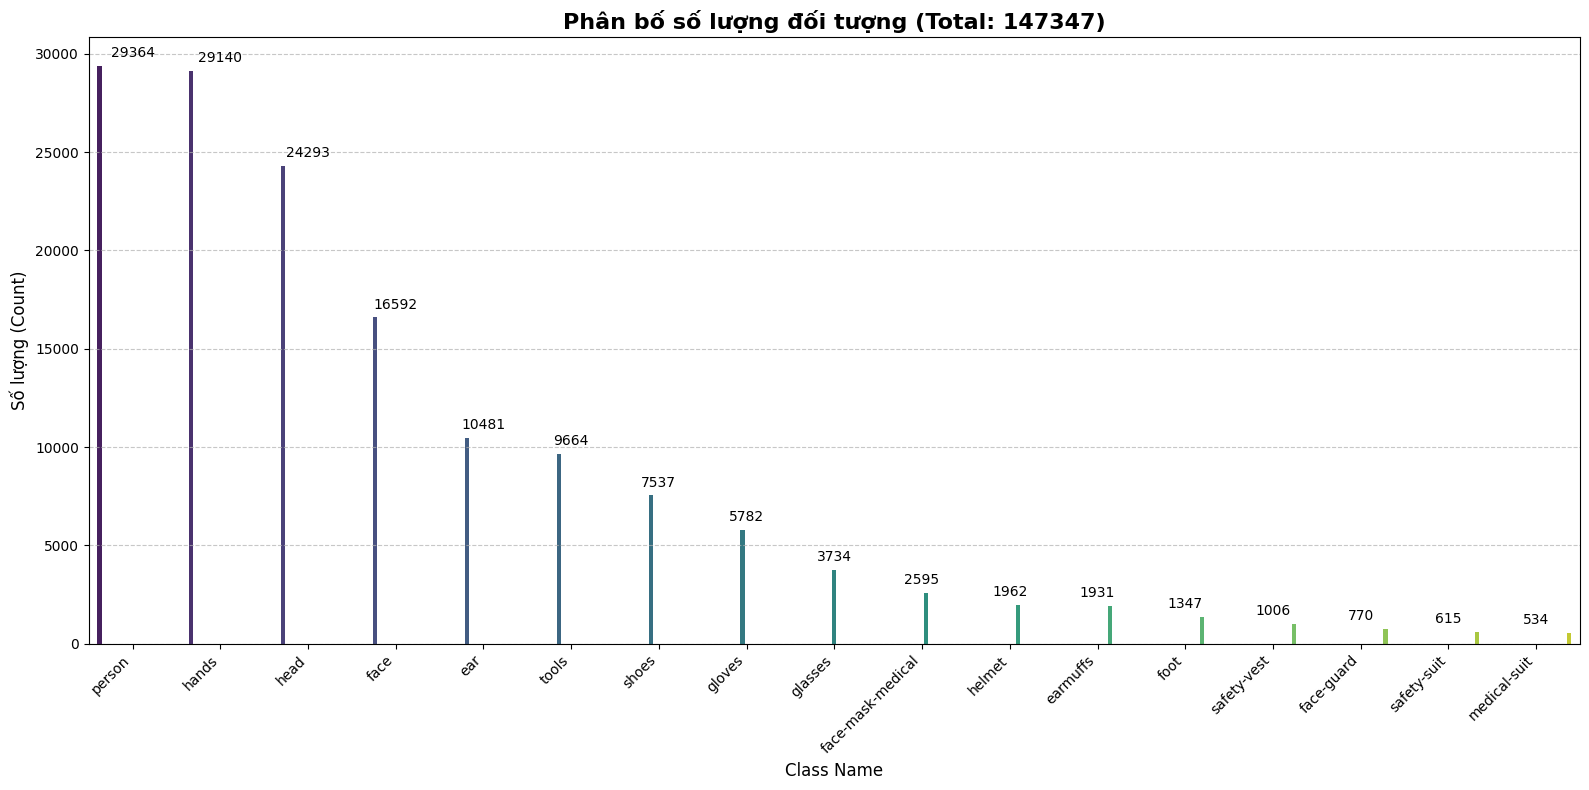


🖼️ Hiển thị 4 ảnh mẫu kèm nhãn...


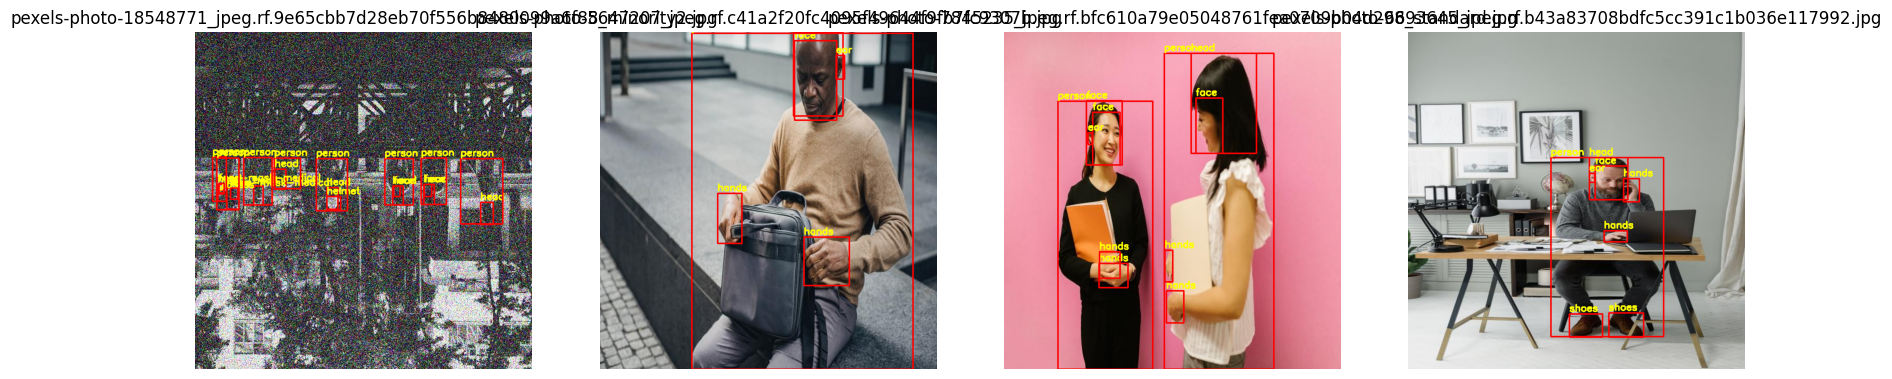

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import random
import os
import yaml
from pathlib import Path
from collections import Counter
from ultralytics import YOLO

# ==========================================
# 1. CẤU HÌNH ĐƯỜNG DẪN
# ==========================================
# Đảm bảo trỏ đúng thư mục dataset đã tạo ở bước trước
DST_ROOT = Path("/kaggle/working/SH17-YOLO-Dataset")
YAML_PATH = DST_ROOT / "data.yaml"

# Mapping tên class
CLASS_NAMES_DICT = {
    0: "ear", 1: "earmuffs", 2: "face", 3: "face-guard",
    4: "face-mask-medical", 5: "foot", 6: "glasses", 7: "gloves",
    8: "hands", 9: "head", 10: "helmet", 11: "medical-suit",
    12: "person", 13: "safety-suit", 14: "safety-vest", 15: "shoes",
    16: "tools"
}

# ==========================================
# 2. ĐÁNH GIÁ DATASET (ĐÃ FIX LỖI)
# ==========================================
def plot_data_distribution():
    print("📊 Đang phân tích phân bố dữ liệu...")
    labels_dir = DST_ROOT / "train/labels"
    cls_counts = Counter()

    # Đếm số lượng object
    txt_files = list(labels_dir.glob("*.txt"))
    if not txt_files:
        print("⚠️ Không tìm thấy file labels nào!")
        return

    for label_file in txt_files:
        with open(label_file, "r") as f:
            lines = f.readlines()
            for line in lines:
                parts = line.strip().split()
                if parts:
                    cls_id = int(parts[0])
                    name = CLASS_NAMES_DICT.get(cls_id, str(cls_id))
                    cls_counts[name] += 1
    
    if cls_counts:
        sorted_counts = dict(sorted(cls_counts.items(), key=lambda item: item[1], reverse=True))
        keys = list(sorted_counts.keys())
        values = list(sorted_counts.values())

        plt.figure(figsize=(16, 8))
        
        # --- FIX LỖI Ở ĐÂY ---
        # Bỏ tham số legend=False, dùng hue=keys để giữ màu sắc
        ax = sns.barplot(x=keys, y=values, palette="viridis", hue=keys)
        
        # Ẩn legend thủ công nếu nó hiện ra
        try:
            if ax.get_legend() is not None:
                ax.get_legend().remove()
        except:
            pass

        plt.title(f"Phân bố số lượng đối tượng (Total: {sum(values)})", fontsize=16, fontweight='bold')
        plt.xlabel("Class Name", fontsize=12)
        plt.ylabel("Số lượng (Count)", fontsize=12)
        plt.xticks(rotation=45, ha="right")
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        
        # Thêm số liệu trên đầu cột
        for i, v in enumerate(values):
            plt.text(i, v + (max(values)*0.01), str(v), ha='center', va='bottom', fontsize=10)
            
        plt.tight_layout()
        plt.show()
    else:
        print("⚠️ Không tìm thấy dữ liệu object nào trong các file labels!")

def visualize_sample(num_samples=4):
    print(f"\n🖼️ Hiển thị {num_samples} ảnh mẫu kèm nhãn...")
    img_dir = DST_ROOT / "train/images"
    lbl_dir = DST_ROOT / "train/labels"
    
    all_imgs = list(img_dir.glob("*.jpg")) + list(img_dir.glob("*.png")) + list(img_dir.glob("*.jpeg"))
    if not all_imgs:
        print("❌ Không tìm thấy ảnh trong thư mục train/images!")
        return

    samples = random.sample(all_imgs, min(num_samples, len(all_imgs)))
    
    plt.figure(figsize=(20, 10))
    for i, img_path in enumerate(samples):
        img = cv2.imread(str(img_path))
        if img is None: continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w, _ = img.shape
        
        lbl_path = lbl_dir / f"{img_path.stem}.txt"
        if lbl_path.exists():
            with open(lbl_path, "r") as f:
                lines = f.readlines()
                for line in lines:
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        cls = int(parts[0])
                        x_c, y_c, bw, bh = map(float, parts[1:5])
                        
                        x1 = int((x_c - bw/2) * w)
                        y1 = int((y_c - bh/2) * h)
                        x2 = int((x_c + bw/2) * w)
                        y2 = int((y_c + bh/2) * h)
                        
                        cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
                        label_text = CLASS_NAMES_DICT.get(cls, str(cls))
                        cv2.putText(img, label_text, (x1, y1 - 5), 
                                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 0), 2)
        
        plt.subplot(1, num_samples, i+1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"{img_path.name}")
    plt.show()

# Chạy phần Visualization
plot_data_distribution()
visualize_sample()

In [6]:
# Force install numpy bản cũ
!pip install "numpy<2.0" --force-reinstall

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 85.8 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
datasets 4.4.1 requires pyarrow>=21.0.0, but you have pyarrow 19.0.1 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
google-colab 1.0.0 requires notebook==6.5.7, but you have notebook 6.5.4 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.2.3 which is incompatible.
google-colab 1.0.0 requires requests==2.32

In [7]:
import numpy
print(f"Phiên bản NumPy hiện tại: {numpy.__version__}")

Phiên bản NumPy hiện tại: 1.26.4


In [8]:
import os
import torch
from ultralytics import YOLO

# ==========================================
# 1. TẠO FILE CONFIG CHO YOLOv12s (SMALL)
# ==========================================
yolov12s_yaml_content = """
# Ultralytics YOLOv12s 🚀
nc: 80
scales:
  # [depth, width, max_channels]
  s: [0.50, 0.50, 1024]  # <--- ĐỔI TỪ n SANG s (Width tăng từ 0.25 lên 0.50)

backbone:
  # [from, repeats, module, args]
  - [-1, 1, Conv, [64, 3, 2]]  # 0-P1/2
  - [-1, 1, Conv, [128, 3, 2]]  # 1-P2/4
  - [-1, 2, C3k2, [256, False, 0.25]]
  - [-1, 1, Conv, [256, 3, 2]]  # 3-P3/8
  - [-1, 2, C3k2, [512, False, 0.25]]
  - [-1, 1, Conv, [512, 3, 2]]  # 5-P4/16
  - [-1, 2, A2C2f, [512, True, 4]] # 6
  - [-1, 1, Conv, [1024, 3, 2]]  # 7-P5/32
  - [-1, 2, A2C2f, [1024, True, 1]] # 8
  - [-1, 1, SPPF, [1024, 5]]  # 9

head:
  - [-1, 1, nn.Upsample, [None, 2, 'nearest']]
  - [[-1, 6], 1, Concat, [1]]  # cat backbone P4
  - [-1, 2, A2C2f, [512, False, -1]]  # 12

  - [-1, 1, nn.Upsample, [None, 2, 'nearest']]
  - [[-1, 4], 1, Concat, [1]]  # cat backbone P3
  - [-1, 2, A2C2f, [256, False, -1]]  # 15 (P3/8-small)

  - [-1, 1, Conv, [256, 3, 2]]
  - [[-1, 12], 1, Concat, [1]]  # cat head P4
  - [-1, 2, A2C2f, [512, False, -1]]  # 18 (P4/16-medium)

  - [-1, 1, Conv, [512, 3, 2]]
  - [[-1, 9], 1, Concat, [1]]  # cat head P5
  - [-1, 2, C3k2, [1024, True]]  # 21 (P5/32-large)

  - [[15, 18, 21], 1, Detect, [nc]]  # Detect(P3, P4, P5)
"""

# Ghi vào file yolov12s.yaml
with open("yolov12s.yaml", "w") as f:
    f.write(yolov12s_yaml_content)

print("✅ Đã tạo file cấu hình 'yolov12s.yaml' (Small Version) thành công!")

# ==========================================
# 2. TRAINING FROM SCRATCH (YOLOv12s)
# ==========================================
print("\n🚀 Bắt đầu Training YOLOv12s (Small)...")

try:
    # Load model từ config Small vừa tạo
    model = YOLO("yolov12s.yaml")
    
    YAML_PATH = "/kaggle/working/SH17-YOLO-Dataset/data.yaml"
    
    results = model.train(
        data=YAML_PATH,
        epochs=100,
        imgsz=640,
        batch=64,        # Nếu lỗi OOM thì giảm xuống 32
        device=[0, 1],   # T4 x2
        project='/kaggle/working/runs/train',
        name='SH17_YOLOv12s_Final', # Đổi tên folder output
        exist_ok=True,
        plots=True,
        scale=0.5, mosaic=1.0, mixup=0.0, copy_paste=0.1
    )
    print("✅ Training hoàn tất.")
    
except Exception as e:
    print(f"❌ Lỗi: {e}")

✅ Đã tạo file cấu hình 'yolov12s.yaml' (Small Version) thành công!

🚀 Bắt đầu Training YOLOv12s (Small)...
New https://pypi.org/project/ultralytics/8.3.234 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.63 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
                                                       CUDA:1 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov12s.yaml, data=/kaggle/working/SH17-YOLO-Dataset/data.yaml, epochs=100, time=None, patience=100, batch=64, imgsz=640, save=True, save_period=-1, cache=False, device=[0, 1], workers=8, project=/kaggle/working/runs/train, name=SH17_YOLOv12s_Final, exist_ok=True, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hyb

100%|██████████| 755k/755k [00:00<00:00, 16.9MB/s]
E0000 00:00:1764770783.032573      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764770783.150751      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

...

                   all       1620      15358      0.672      0.503      0.543      0.342

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


    100/100      13.8G     0.9348     0.6486      1.125        124        640: 100%|██████████| 203/203 [04:01<00:00,  1.19s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 26/26 [00:24<00:00,  1.05it/s]


                   all       1620      15358       0.67      0.504      0.544      0.342

100 epochs completed in 7.440 hours.
Optimizer stripped from /kaggle/working/runs/train/SH17_YOLOv12s_Final/weights/last.pt, 18.7MB
Optimizer stripped from /kaggle/working/runs/train/SH17_YOLOv12s_Final/weights/best.pt, 18.7MB

Validating /kaggle/working/runs/train/SH17_YOLOv12s_Final/weights/best.pt...
Ultralytics 8.3.63 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
                                                       CUDA:1 (Tesla T4, 15095MiB)
YOLOv12s summary (fused): 376 layers, 9,080,787 parameters, 0 gradients, 19.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 26/26 [00:26<00:00,  1.02s/it]


                   all       1620      15358       0.67      0.504      0.544      0.342
                   ear        987       1612      0.897      0.669      0.741      0.444
              earmuffs         38         49      0.346      0.245      0.246      0.113
                  face       1155       1855      0.949      0.866      0.911      0.676
            face-guard         23         24      0.492      0.375      0.333      0.202
     face-mask-medical         75        151      0.799      0.689      0.718      0.413
                  foot         64        149      0.567      0.047      0.123     0.0527
               glasses        323        398      0.736      0.555      0.619      0.309
                gloves        254        529      0.582      0.399      0.438      0.264
                 hands       1284       3212       0.84      0.769      0.825      0.539
                  head       1314       2427      0.929      0.854      0.902      0.692
                helme

📦 Loading best model: /kaggle/working/runs/train/SH17_YOLOv12s_Final/weights/best.pt...

📊 KẾT QUẢ ĐÁNH GIÁ (VALIDATION SET)
Ultralytics 8.3.63 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv12s summary (fused): 376 layers, 9,080,787 parameters, 0 gradients, 19.3 GFLOPs


val: Scanning /kaggle/working/SH17-YOLO-Dataset/valid/labels.cache... 1620 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1620/1620 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 102/102 [00:49<00:00,  2.08it/s]


                   all       1620      15358       0.67      0.504      0.544      0.342


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


Speed: 0.2ms preprocess, 24.4ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to /kaggle/working/yolov12/runs/detect/val2
   Precision (P):  0.6703
   Recall (R):     0.5038
   mAP@50:         0.5436
   mAP@50-95:      0.3419

🔮 PREDICT ẢNH TEST:


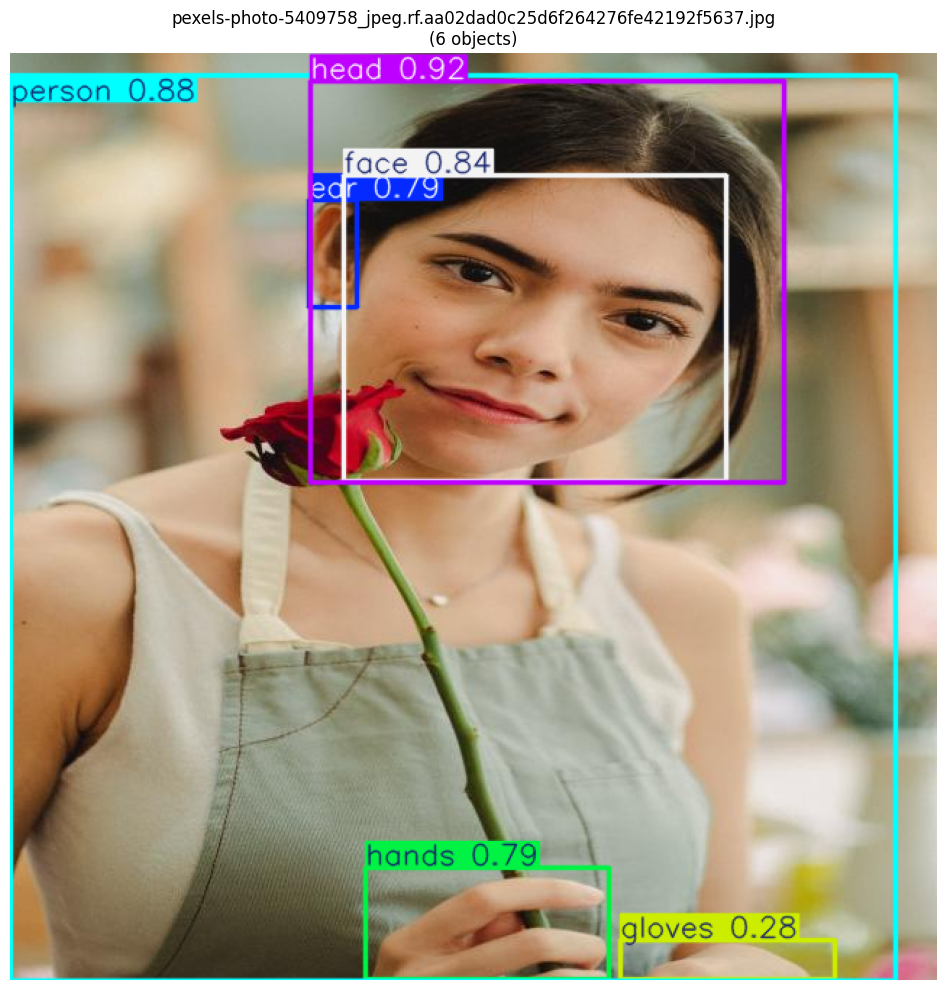

In [10]:
import matplotlib.pyplot as plt
import cv2
import random
from ultralytics import YOLO
from pathlib import Path

# 1. Tìm file weights tốt nhất
weights_files = list(Path('/kaggle/working/runs/train').rglob('best.pt'))

if not weights_files:
    print("❌ Lỗi: Không tìm thấy file 'best.pt'. Có thể quá trình train bị lỗi hoặc chưa xong.")
else:
    # Lấy file mới nhất (của lần train v12s vừa xong)
    best_weight = weights_files[-1] 
    print(f"📦 Loading best model: {best_weight}...")
    
    model = YOLO(best_weight)
    
    # -------------------------------------------------------
    # 2. ĐÁNH GIÁ METRICS
    # -------------------------------------------------------
    print("\n" + "="*40)
    print("📊 KẾT QUẢ ĐÁNH GIÁ (VALIDATION SET)")
    print("="*40)
    
    metrics = model.val(split='val', verbose=False)
    
    p = metrics.box.mp
    r = metrics.box.mr
    map50 = metrics.box.map50
    map5095 = metrics.box.map
    
    print(f"   Precision (P):  {p:.4f}")
    print(f"   Recall (R):     {r:.4f}")
    print(f"   mAP@50:         {map50:.4f}")
    print(f"   mAP@50-95:      {map5095:.4f}")
    print("="*40)

    # -------------------------------------------------------
    # 3. DỰ ĐOÁN TẬP TEST
    # -------------------------------------------------------
    print("\n🔮 PREDICT ẢNH TEST:")
    DST_ROOT = Path("/kaggle/working/SH17-YOLO-Dataset")
    test_imgs = list((DST_ROOT / "test/images").glob("*.*"))
    
    if test_imgs:
        samples = random.sample(test_imgs, min(3, len(test_imgs)))
        if len(samples) == 1:
            fig_size = (10, 10); cols = 1
        else:
            fig_size = (6 * len(samples), 6); cols = len(samples)
            
        plt.figure(figsize=fig_size)
        for i, img_path in enumerate(samples):
            res = model.predict(str(img_path), conf=0.25, verbose=False)[0]
            img_plotted = res.plot()
            plt.subplot(1, cols, i+1)
            plt.imshow(cv2.cvtColor(img_plotted, cv2.COLOR_BGR2RGB))
            plt.axis('off')
            plt.title(f"{img_path.name}\n({len(res.boxes)} objects)", fontsize=12)
        plt.tight_layout()
        plt.show()
    else:
        print("⚠️ Thư mục test trống.")